# 🌿 Mango Leaf Disease — ResNet50 (Balanced)
**Dataset:** https://data.mendeley.com/datasets/7ghdbftp54/1  


In [ ]:
# ── 1. Libraries ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import os, cv2, random, time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: []


In [ ]:
# ── Step 2: Find Your Dataset Path ────────────────────────────────────────
import os
from google.colab import drive

# Mount Google Drive if it's not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print('/content/drive already mounted.')

# Check what's in your Drive
base = '/content/drive/MyDrive'
print("\nFolders in your Drive:")
if os.path.exists(base):
    for item in os.listdir(base):
        print(' ', item)
else:
    print(f"Error: The directory {base} does not exist after mounting.")

Mounted at /content/drive

Folders in your Drive:
  Classroom
  IMG_4432.HEIC.heif
  NID.pdf
  CASE STUDY 
  Contact Information (Responses).gsheet
  My documents 
  Eva's assignment
  Cover page esha.docx
  Colab Notebooks
  remote sound soft
  esha.docx
  esha1.docx
  Nishat cv.docx
  1.jpg
  Untitled document.gdoc
  MFA_1908001_&_1908044 (Defence).pdf
  Rakibul Hasan Nishat (7).pdf
  Rakibul Hasan Nishat (6).pdf
  Rakibul Hasan Nishat (5).pdf
  apply format.gdoc
  Rakibul Hasan Nishat (4).pdf
  Rakibul Hasan Nishat (3).pdf
  Rakibul Hasan Nishat (2).pdf
  Rakibul Hasan Nishat (1).pdf
  Thesis book report 
  1908001___1908044_Thesis_Book.docx
  SQL.gdoc
  Nishat cv (Revised).pdf
  Rakibul Hasan Nishat.pdf
  Rakibul_Hasan_Nishat.pdf
  Nishat cv (1).docx
  P.gdoc
  RA.gdoc
  Interview Questions .gdoc
  article-template.docx
  1998_Response-to-Reviewers-Comments.docx
  20260102_121934.mp4
  PUBLICATION
  preview-9780192550064_A35506325_copy.pdf
  ML.docx
  Mango Dataset


In [ ]:
# ── Step 3: Set Your Dataset Path ─────────────────────────────────────────
# Replace 'JOURNAL MANGO' with your actual folder name from Step 2
dataset_dir = '/content/drive/MyDrive/Mango Dataset'

# Verify it works
print('Folder exists:', os.path.exists(dataset_dir))
print('\nClasses found:')
for item in os.listdir(dataset_dir):
    full_path = os.path.join(dataset_dir, item)
    if os.path.isdir(full_path):
        count = len([f for f in os.listdir(full_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f'  {item:<25} → {count} images')

Folder exists: True

Classes found:
  Powdery Mildew            → 206 images
  Gall Midge                → 319 images
  Sooty Mould               → 265 images
  Die Back                  → 320 images
  Healthy                   → 250 images
  Cutting Weevil            → 307 images
  Bacterial Canker          → 360 images
  Anthracnose               → 326 images


In [ ]:
# ── 3. Build DataFrame ──────────────────────────────────────────────
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff'}

data, labels = [], []
for cls in os.listdir(dataset_dir):
    cls_path = os.path.join(dataset_dir, cls)
    if not os.path.isdir(cls_path): continue
    for file in os.listdir(cls_path):
        if os.path.splitext(file)[1].lower() in VALID_EXTS:
            data.append(os.path.join(cls_path, file))
            labels.append(cls)

df = pd.concat([pd.Series(data,   name='paths'),
                pd.Series(labels, name='labels')], axis=1)
print(f'Total images : {len(df)}')
print('\nClass distribution:')
print(df['labels'].value_counts())

Total images : 2353

Class distribution:
labels
Bacterial Canker    360
Anthracnose         326
Die Back            320
Gall Midge          319
Cutting Weevil      307
Sooty Mould         265
Healthy             250
Powdery Mildew      206
Name: count, dtype: int64


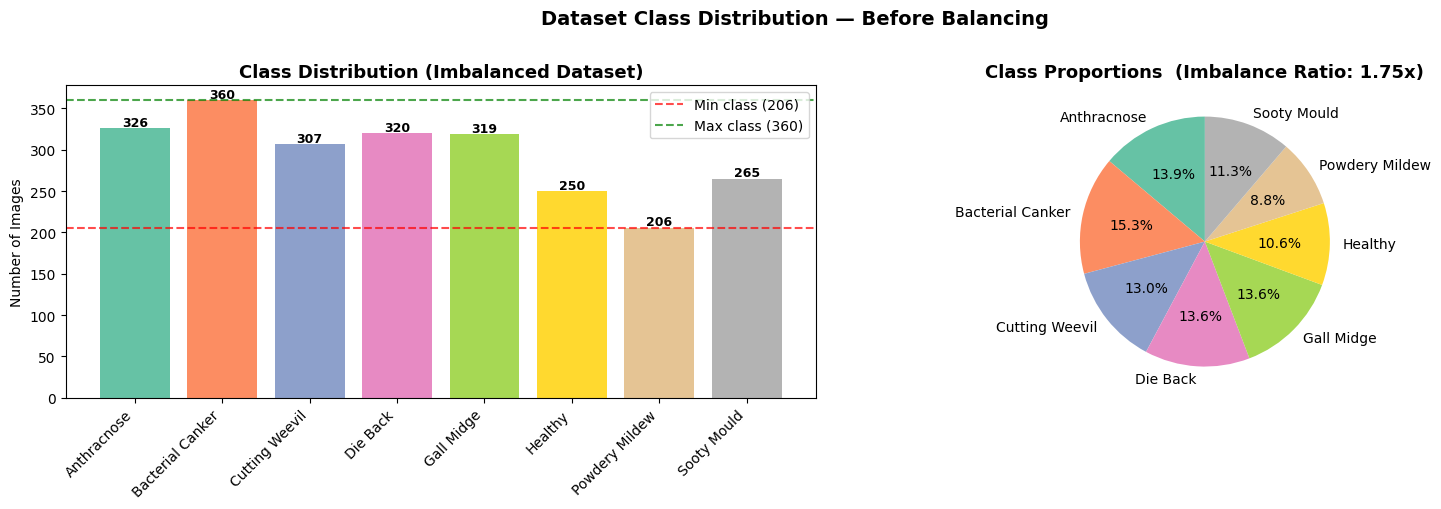


Imbalance ratio (max/min): 1.75x
Most common class : Bacterial Canker (360 images)
Rarest class      : Powdery Mildew (206 images)


In [ ]:
# ── 4. Class Distribution Plot ──────────────────────────────────────
counts = df['labels'].value_counts().sort_index()
MIN_COUNT = counts.min()
MAX_COUNT = counts.max()
IMBALANCE_RATIO = MAX_COUNT / MIN_COUNT

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors_bar = sns.color_palette('Set2', len(counts))
bars = axes[0].bar(counts.index, counts.values, color=colors_bar)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(val), ha='center', fontsize=9, fontweight='bold')
axes[0].axhline(MIN_COUNT, color='red', linestyle='--',
                alpha=0.7, label=f'Min class ({MIN_COUNT})')
axes[0].axhline(MAX_COUNT, color='green', linestyle='--',
                alpha=0.7, label=f'Max class ({MAX_COUNT})')
axes[0].set_title('Class Distribution (Imbalanced Dataset)',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')
axes[0].legend()

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=colors_bar, startangle=90)
axes[1].set_title(f'Class Proportions  (Imbalance Ratio: {IMBALANCE_RATIO:.2f}x)',
                   fontsize=13, fontweight='bold')

plt.suptitle('Dataset Class Distribution — Before Balancing',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nImbalance ratio (max/min): {IMBALANCE_RATIO:.2f}x')
print(f'Most common class : {counts.idxmax()} ({MAX_COUNT} images)')
print(f'Rarest class      : {counts.idxmin()} ({MIN_COUNT} images)')

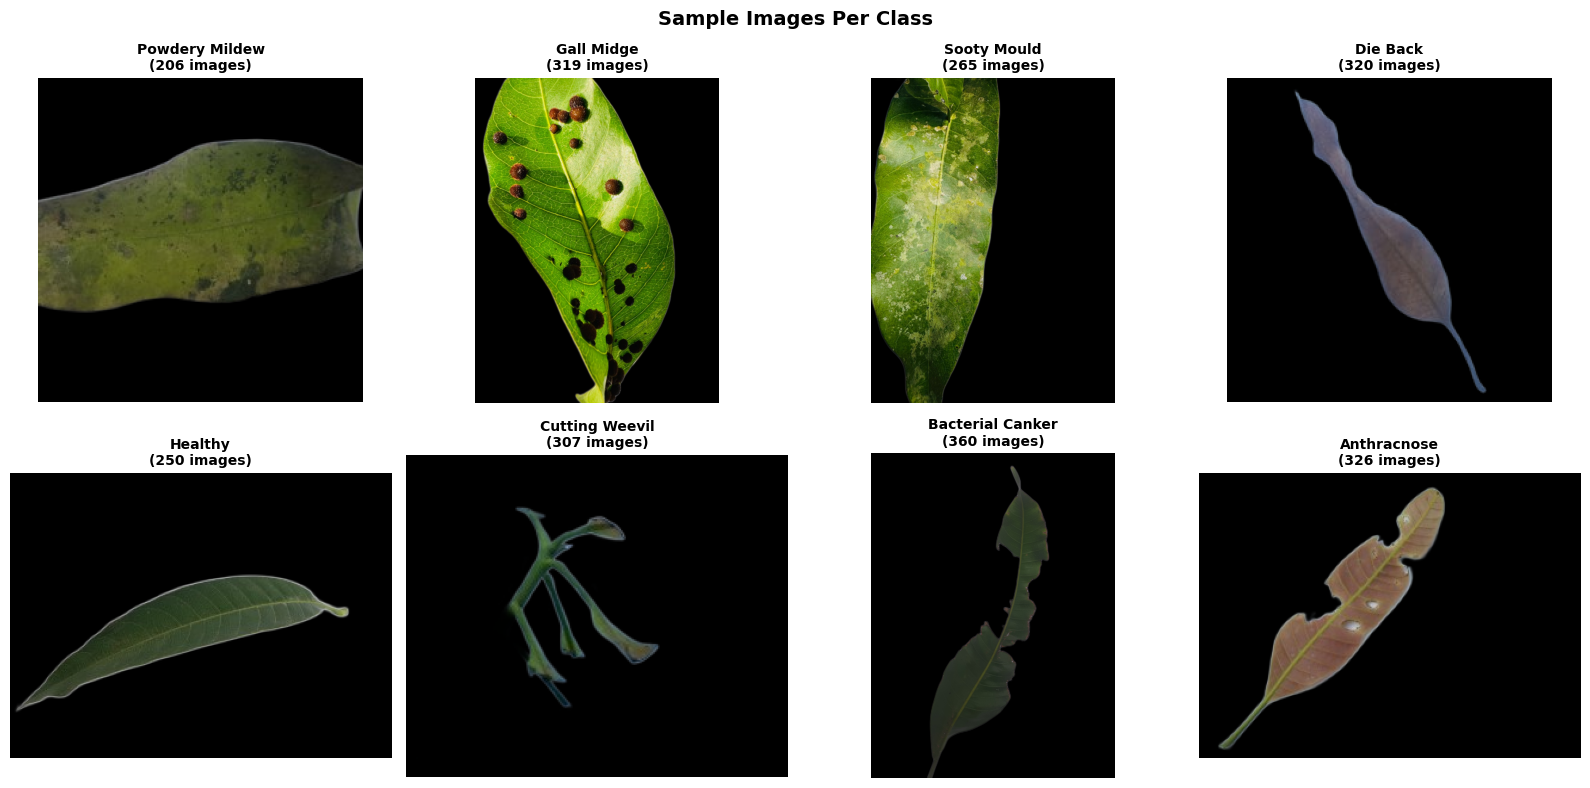

In [ ]:
# ── 5. Sample Images Per Class ──────────────────────────────────────
classes = df['labels'].unique()
cols = 4; rows = (len(classes) + cols - 1) // cols
plt.figure(figsize=(16, 4 * rows))
for idx, cls in enumerate(classes):
    img_path = random.choice(df[df['labels'] == cls]['paths'].values)
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax = plt.subplot(rows, cols, idx + 1)
    ax.imshow(img); ax.axis('off')
    count = len(df[df['labels'] == cls])
    ax.set_title(f'{cls}\n({count} images)', fontsize=10, fontweight='bold')
plt.suptitle('Sample Images Per Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Train : 1882 images
Val   : 235 images
Test  : 236 images


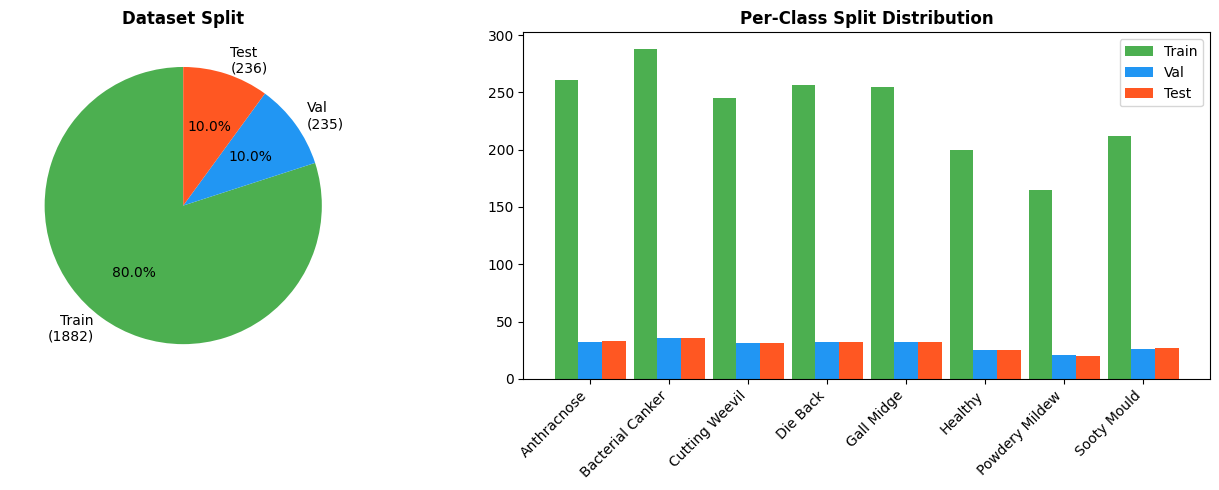

In [ ]:
# ── 6. Train / Validation / Test Split ─────────────────────────────
# stratify ensures each split preserves the class distribution
train_df, temp_df = train_test_split(df, test_size=0.2,
                                      stratify=df['labels'], random_state=42)
val_df,   test_df  = train_test_split(temp_df, test_size=0.5,
                                      stratify=temp_df['labels'], random_state=42)

print(f'Train : {len(train_df)} images')
print(f'Val   : {len(val_df)} images')
print(f'Test  : {len(test_df)} images')

# Split distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sizes = [len(train_df), len(val_df), len(test_df)]
axes[0].pie(sizes,
            labels=[f'Train\n({sizes[0]})', f'Val\n({sizes[1]})', f'Test\n({sizes[2]})'],
            autopct='%1.1f%%', colors=['#4CAF50','#2196F3','#FF5722'],
            startangle=90)
axes[0].set_title('Dataset Split', fontweight='bold')

tc  = train_df['labels'].value_counts().sort_index()
vc  = val_df['labels'].value_counts().sort_index()
tsc = test_df['labels'].value_counts().sort_index()
x = np.arange(len(tc)); w = 0.3
axes[1].bar(x - w, tc.values,  w, label='Train', color='#4CAF50')
axes[1].bar(x,     vc.values,  w, label='Val',   color='#2196F3')
axes[1].bar(x + w, tsc.values, w, label='Test',  color='#FF5722')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tc.index, rotation=45, ha='right')
axes[1].set_title('Per-Class Split Distribution', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

## ⚖️ Balancing Strategy

This notebook uses **two complementary techniques** to handle class imbalance:

1. **Class Weights** — Assigned to `model.fit()`. The loss function penalizes misclassifications of minority classes more heavily. Computed as `n_samples / (n_classes × class_count)` — rarer classes get higher weights.

2. **Oversampling** — Minority class rows are duplicated in the training DataFrame until every class has the same number of images as the majority class. Combined with augmentation, each duplicate receives a different random transformation so the model never sees identical images.

**Validation and Test sets are NOT resampled** — they must reflect real-world class distribution for honest evaluation.

Class Weights (higher = rarer class):
  [0] Anthracnose          weight = 0.9013
  [1] Bacterial Canker     weight = 0.8168
  [2] Cutting Weevil       weight = 0.9602
  [3] Die Back             weight = 0.9189
  [4] Gall Midge           weight = 0.9225
  [5] Healthy              weight = 1.1763
  [6] Powdery Mildew       weight = 1.4258
  [7] Sooty Mould          weight = 1.1097

Original train size : 1882
Balanced train size : 2304

Balanced distribution:
labels
Healthy             288
Gall Midge          288
Powdery Mildew      288
Die Back            288
Cutting Weevil      288
Sooty Mould         288
Anthracnose         288
Bacterial Canker    288
Name: count, dtype: int64


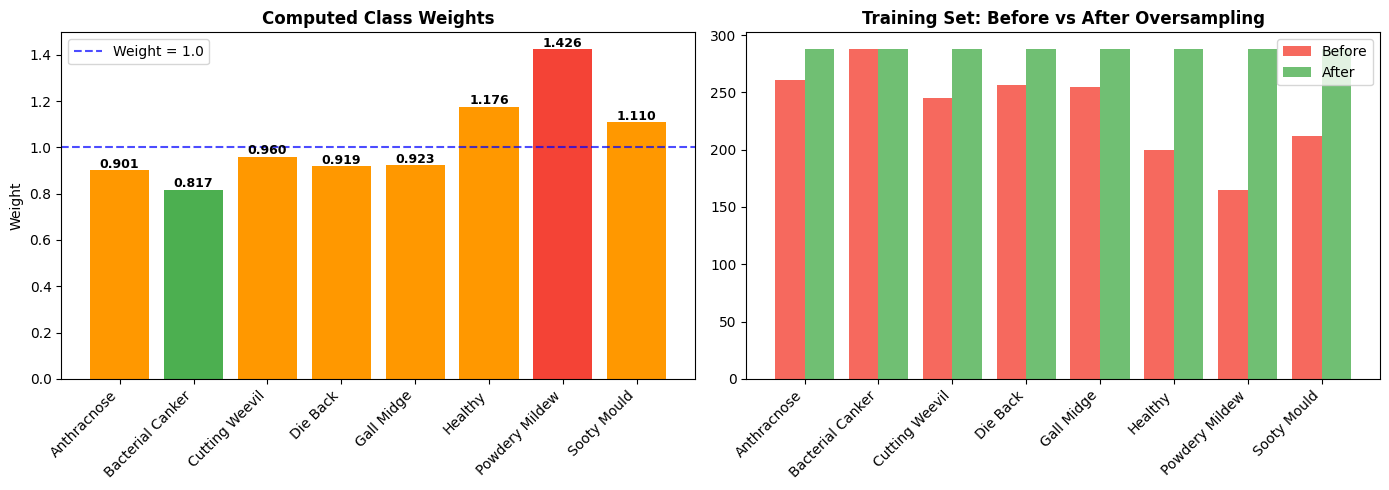

In [ ]:
# ── 7. Class Weights Computation ────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

label_series = train_df['labels']
unique_classes = np.array(sorted(label_series.unique()))

raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=label_series
)
class_weight_dict = dict(enumerate(raw_weights))

print('Class Weights (higher = rarer class):')
for i, cls in enumerate(unique_classes):
    print(f'  [{i}] {cls:<20} weight = {raw_weights[i]:.4f}')

# Visualise class weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_w = ['#F44336' if w > 1.2 else '#FF9800' if w > 0.9 else '#4CAF50'
            for w in raw_weights]
bars_w = axes[0].bar(unique_classes, raw_weights, color=colors_w)
for bar, val in zip(bars_w, raw_weights):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].axhline(1.0, color='blue', linestyle='--', alpha=0.7, label='Weight = 1.0')
axes[0].set_xticklabels(unique_classes, rotation=45, ha='right')
axes[0].set_title('Computed Class Weights', fontweight='bold')
axes[0].set_ylabel('Weight'); axes[0].legend()

# ── 8. Oversampling (upsample minority classes in train_df) ─────
MAX_SAMPLES = train_df['labels'].value_counts().max()

balanced_parts = []
for cls in train_df['labels'].unique():
    cls_df = train_df[train_df['labels'] == cls]
    if len(cls_df) < MAX_SAMPLES:
        # Sample with replacement to reach MAX_SAMPLES
        extras = cls_df.sample(MAX_SAMPLES - len(cls_df),
                               replace=True, random_state=42)
        cls_df = pd.concat([cls_df, extras], ignore_index=True)
    balanced_parts.append(cls_df)

train_df_bal = pd.concat(balanced_parts, ignore_index=True).sample(
    frac=1, random_state=42).reset_index(drop=True)

print(f'\nOriginal train size : {len(train_df)}')
print(f'Balanced train size : {len(train_df_bal)}')
print('\nBalanced distribution:')
print(train_df_bal['labels'].value_counts())

# Plot before vs after
before = train_df['labels'].value_counts().sort_index()
after  = train_df_bal['labels'].value_counts().sort_index()
x2 = np.arange(len(before)); w2 = 0.4
axes[1].bar(x2 - w2/2, before.values, w2, label='Before', color='#F44336', alpha=0.8)
axes[1].bar(x2 + w2/2, after.values,  w2, label='After',  color='#4CAF50', alpha=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(before.index, rotation=45, ha='right')
axes[1].set_title('Training Set: Before vs After Oversampling', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

# Use balanced train_df going forward
TRAIN_DF = train_df_bal
USE_CLASS_WEIGHT = class_weight_dict  # passed to model.fit()

In [ ]:
# ── 8. Data Generators & Augmentation ──────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Training: heavy augmentation to prevent overfitting
train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
# Val & Test: only normalize, NO augmentation
val_gen  = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input)
test_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input)

train_flow = train_gen.flow_from_dataframe(
    TRAIN_DF, x_col='paths', y_col='labels',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True)

val_flow = val_gen.flow_from_dataframe(
    val_df, x_col='paths', y_col='labels',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

test_flow = test_gen.flow_from_dataframe(
    test_df, x_col='paths', y_col='labels',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

CLASS_NAMES = list(train_flow.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)

# Reorder class_weight_dict to match generator class_indices
# Map string labels to generator integer indices for class_weight
label_to_idx = train_flow.class_indices
from sklearn.utils.class_weight import compute_class_weight
cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(TRAIN_DF['labels'].unique())),
    y=TRAIN_DF['labels']
)
# Build dict keyed by generator integer index
USE_CLASS_WEIGHT = {label_to_idx[cls]: w
                    for cls, w in zip(sorted(TRAIN_DF['labels'].unique()), cw_array)}
print('Class weight mapping:', USE_CLASS_WEIGHT)


Found 2304 validated image filenames belonging to 8 classes.
Found 235 validated image filenames belonging to 8 classes.
Found 236 validated image filenames belonging to 8 classes.
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Class weight mapping: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0)}


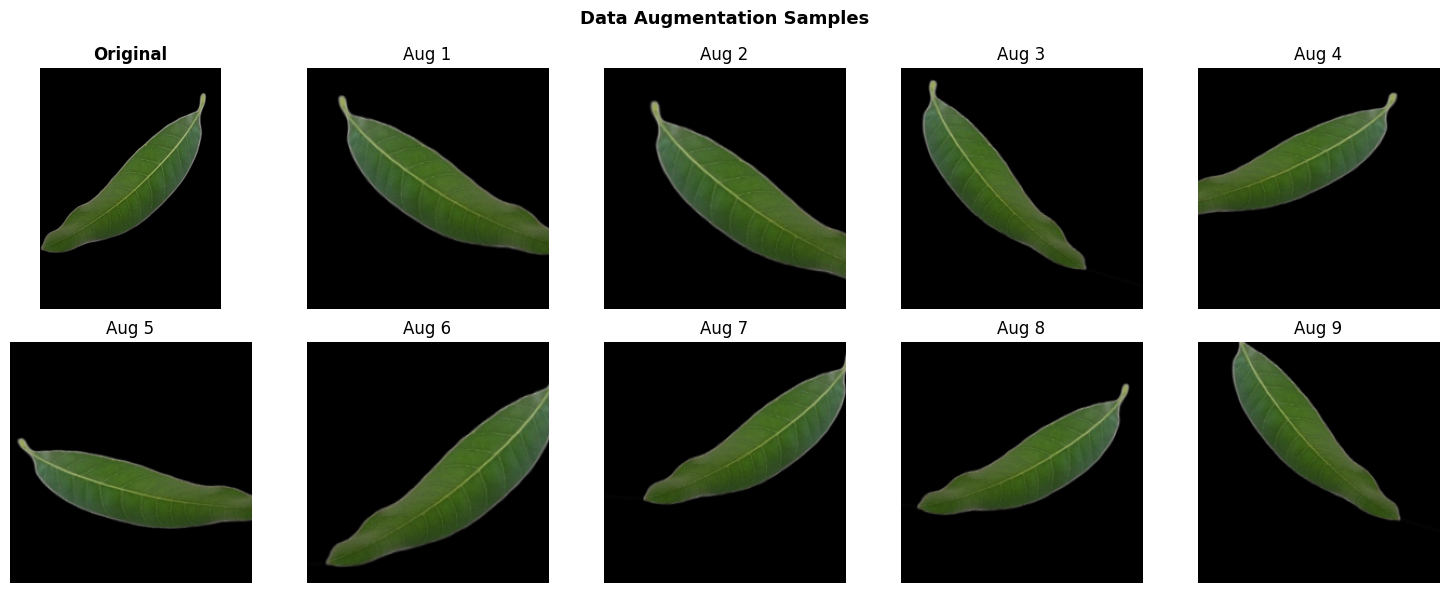

In [ ]:
# ── 9. Augmentation Preview ─────────────────────────────────────────
sample_img = cv2.cvtColor(
    cv2.imread(TRAIN_DF.iloc[0]['paths']), cv2.COLOR_BGR2RGB)
sample_arr = np.expand_dims(cv2.resize(sample_img, (224, 224)), 0)

aug_preview = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    zoom_range=0.15, horizontal_flip=True, fill_mode='nearest')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original', fontweight='bold'); axes[0, 0].axis('off')
aug_it = aug_preview.flow(sample_arr, batch_size=1)
for i, ax in enumerate(axes.flatten()[1:]):
    ax.imshow(next(aug_it)[0].astype(np.uint8))
    ax.set_title(f'Aug {i+1}'); ax.axis('off')
plt.suptitle('Data Augmentation Samples', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── 10. Build ResNet50 Model ────────────────────────────────────
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Phase 1: freeze base

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,773,256 (94.50 MB)

 Trainable params: 1,184,008 (4.52 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [ ]:
# ── 11. Callbacks ───────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint('resnet50_balanced_best.keras',
                    monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-8, verbose=1)
]

In [16]:
# ── 12. Phase 1: Train Classification Head (base frozen) ────────────
print('=======================================================')
print('PHASE 1 — Training head | ResNet50 | Balanced')
print('=======================================================')
start = time.time()
history1 = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=30,
    class_weight=USE_CLASS_WEIGHT,
    callbacks=callbacks
)
print(f'Phase 1 training time: {(time.time()-start)/60:.1f} min')

PHASE 1 — Training head | ResNet50 | Balanced
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3407 - loss: 2.4017
Epoch 1: val_loss improved from None to 0.81043, saving model to resnet50_balanced_best.keras

Epoch 1: finished saving model to resnet50_balanced_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 792s 11s/step - accuracy: 0.5065 - loss: 1.7176 - val_accuracy: 0.8213 - val_loss: 0.8104 - learning_rate: 1.0000e-04
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7278 - loss: 0.9057
Epoch 2: val_loss improved from 0.81043 to 0.53069, saving model to resnet50_balanced_best.keras

Epoch 2: finished saving model to resnet50_balanced_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 513s 7s/step - accuracy: 0.7635 - loss: 0.8230 - val_accuracy: 0.8766 - val_loss: 0.5307 - learning_rate: 1.0000e-04
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8495 - loss: 0.6092
Epoch 3: val_loss improved from 0.53069 to 0.40582, saving model to resnet50_balanced_best.keras


In [17]:
# ── 13. Phase 2: Fine-Tuning ────────────────────────────────────────
print('Phase 2 — Fine-tuning | Freeze layers 0-142, unfreeze last ResNet block')
# Freeze layers 0-142, unfreeze last ResNet block
base_model.trainable = True
for layer in base_model.layers[:143]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy', metrics=['accuracy'])

start = time.time()
history2 = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=20,
    class_weight=USE_CLASS_WEIGHT,
    callbacks=callbacks
)
print(f'Phase 2 training time: {(time.time()-start)/60:.1f} min')

Phase 2 — Fine-tuning | Freeze layers 0-142, unfreeze last ResNet block
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9192 - loss: 0.3479
Epoch 1: val_loss did not improve from 0.18738
72/72 ━━━━━━━━━━━━━━━━━━━━ 770s 10s/step - accuracy: 0.9327 - loss: 0.3263 - val_accuracy: 0.9787 - val_loss: 0.1955 - learning_rate: 1.0000e-05
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9431 - loss: 0.2803
Epoch 2: val_loss did not improve from 0.18738
72/72 ━━━━━━━━━━━━━━━━━━━━ 717s 10s/step - accuracy: 0.9418 - loss: 0.2818 - val_accuracy: 0.9787 - val_loss: 0.2067 - learning_rate: 1.0000e-05
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9450 - loss: 0.2770
Epoch 3: val_loss did not improve from 0.18738

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
72/72 ━━━━━━━━━━━━━━━━━━━━ 709s 10s/step - accuracy: 0.9549 - loss: 0.2526 - val_accuracy: 0.9702 - val_loss: 0.2090 - learning_rate: 1.0000e-05
Epoch 4/20
72/72 ━━━━━━━━

In [18]:
# ── 14. Merge Histories ─────────────────────────────────────────────
history = {k: history1.history[k] + history2.history[k]
           for k in history1.history}
phase1_len = len(history1.history['loss'])
epochs_range = range(1, len(history['accuracy']) + 1)

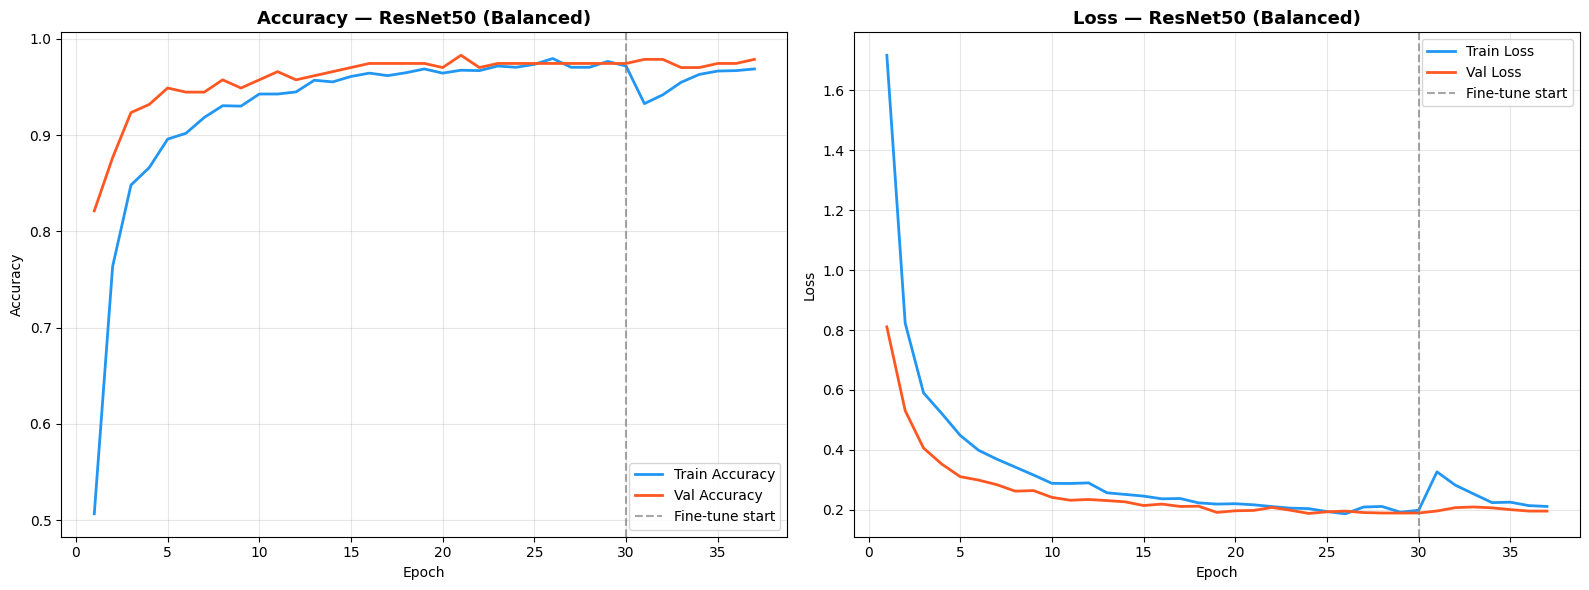

In [19]:
# ── 15. Training Curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(epochs_range, history['accuracy'],
             label='Train Accuracy', color='#2196F3', lw=2)
axes[0].plot(epochs_range, history['val_accuracy'],
             label='Val Accuracy', color='#FF5722', lw=2)
axes[0].axvline(phase1_len, color='gray', linestyle='--',
                alpha=0.7, label='Fine-tune start')
axes[0].set_title('Accuracy — ResNet50 (Balanced)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['loss'],
             label='Train Loss', color='#2196F3', lw=2)
axes[1].plot(epochs_range, history['val_loss'],
             label='Val Loss', color='#FF5722', lw=2)
axes[1].axvline(phase1_len, color='gray', linestyle='--',
                alpha=0.7, label='Fine-tune start')
axes[1].set_title('Loss — ResNet50 (Balanced)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

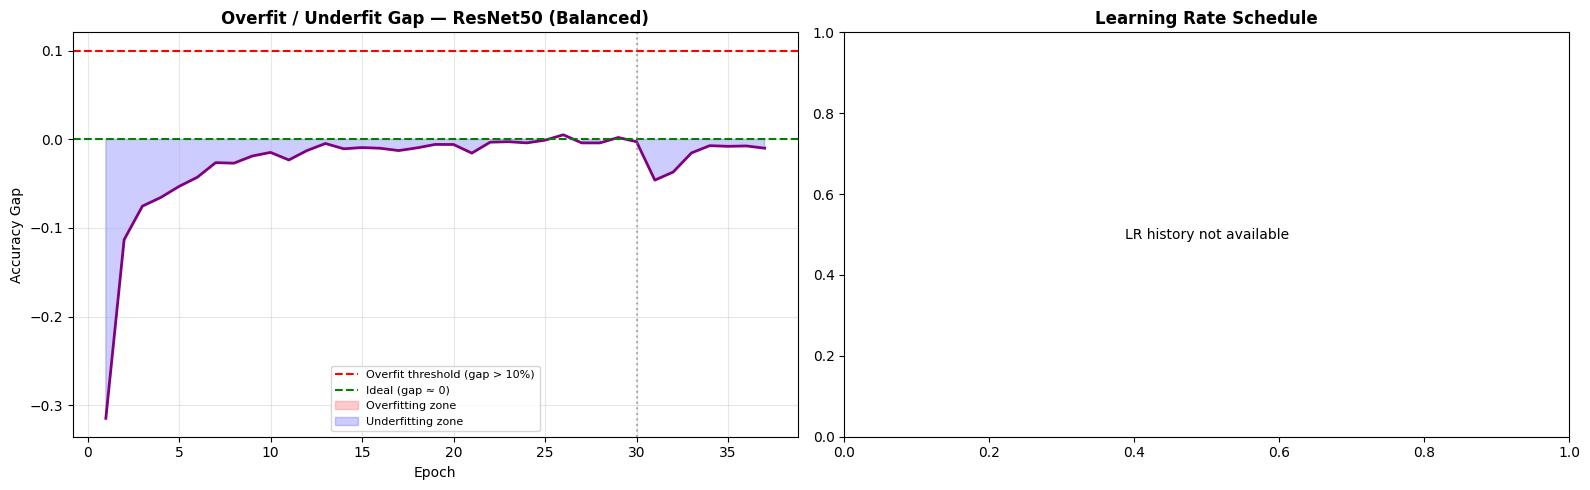

In [20]:
# ── 16. Overfitting / Underfitting Diagnostic ───────────────────────
train_acc = np.array(history['accuracy'])
val_acc   = np.array(history['val_accuracy'])
gap       = train_acc - val_acc

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs_range, gap, color='purple', lw=2)
axes[0].axhline(0.10, color='red',   linestyle='--',
                label='Overfit threshold (gap > 10%)')
axes[0].axhline(0.00, color='green', linestyle='--', label='Ideal (gap ≈ 0)')
axes[0].fill_between(epochs_range, gap, 0.10,
    where=(gap > 0.10), alpha=0.2, color='red',  label='Overfitting zone')
axes[0].fill_between(epochs_range, gap, 0.00,
    where=(gap < 0.00), alpha=0.2, color='blue', label='Underfitting zone')
axes[0].axvline(phase1_len, color='gray', linestyle=':', alpha=0.6)
axes[0].set_title('Overfit / Underfit Gap — ResNet50 (Balanced)',
                   fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy Gap')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

if 'lr' in history:
    axes[1].plot(epochs_range, history['lr'], color='darkorange', lw=2)
    axes[1].set_yscale('log')
    axes[1].set_title('Learning Rate Schedule', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR (log scale)')
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'LR history not available',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Learning Rate Schedule', fontweight='bold')
plt.tight_layout(); plt.show()

In [21]:
# ── 17. Load Best Model & Predict on Test Set ───────────────────────
best_model = tf.keras.models.load_model('resnet50_balanced_best.keras')

y_true  = test_flow.classes
y_proba = best_model.predict(test_flow, verbose=1)
y_pred  = np.argmax(y_proba, axis=1)

print('\n── Classification Report ──')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f'Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}')

8/8 ━━━━━━━━━━━━━━━━━━━━ 76s 10s/step

── Classification Report ──
                  precision    recall  f1-score   support

     Anthracnose       1.00      0.91      0.95        33
Bacterial Canker       0.95      1.00      0.97        36
  Cutting Weevil       1.00      1.00      1.00        31
        Die Back       1.00      1.00      1.00        32
      Gall Midge       1.00      1.00      1.00        32
         Healthy       0.96      1.00      0.98        25
  Powdery Mildew       1.00      1.00      1.00        20
     Sooty Mould       1.00      1.00      1.00        27

        accuracy                           0.99       236
       macro avg       0.99      0.99      0.99       236
    weighted avg       0.99      0.99      0.99       236

Overall Accuracy: 0.9873


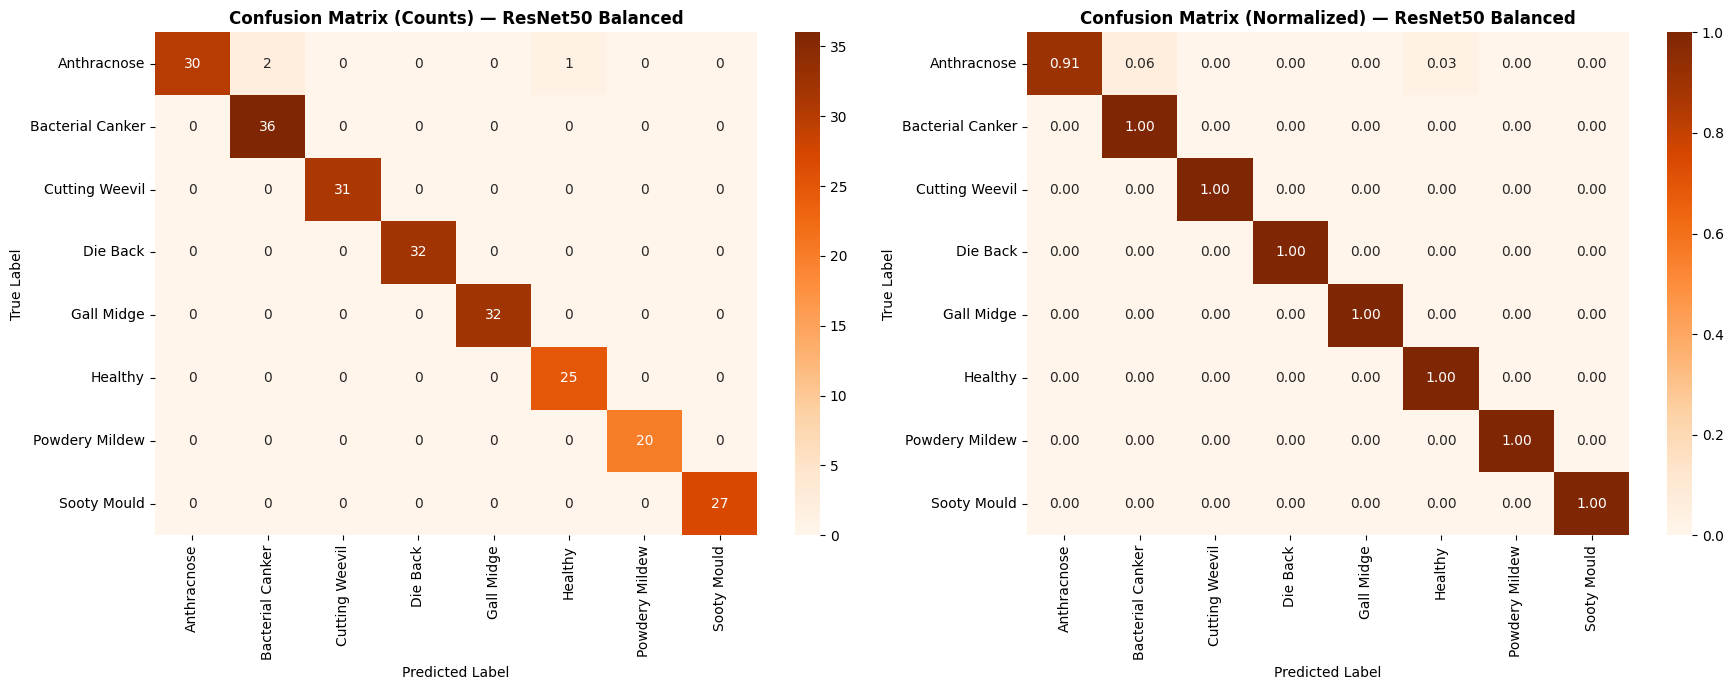

In [22]:
# ── 18. Confusion Matrix (Raw + Normalized) ─────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts) — ResNet50 Balanced',
                   fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized) — ResNet50 Balanced',
                   fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout(); plt.show()

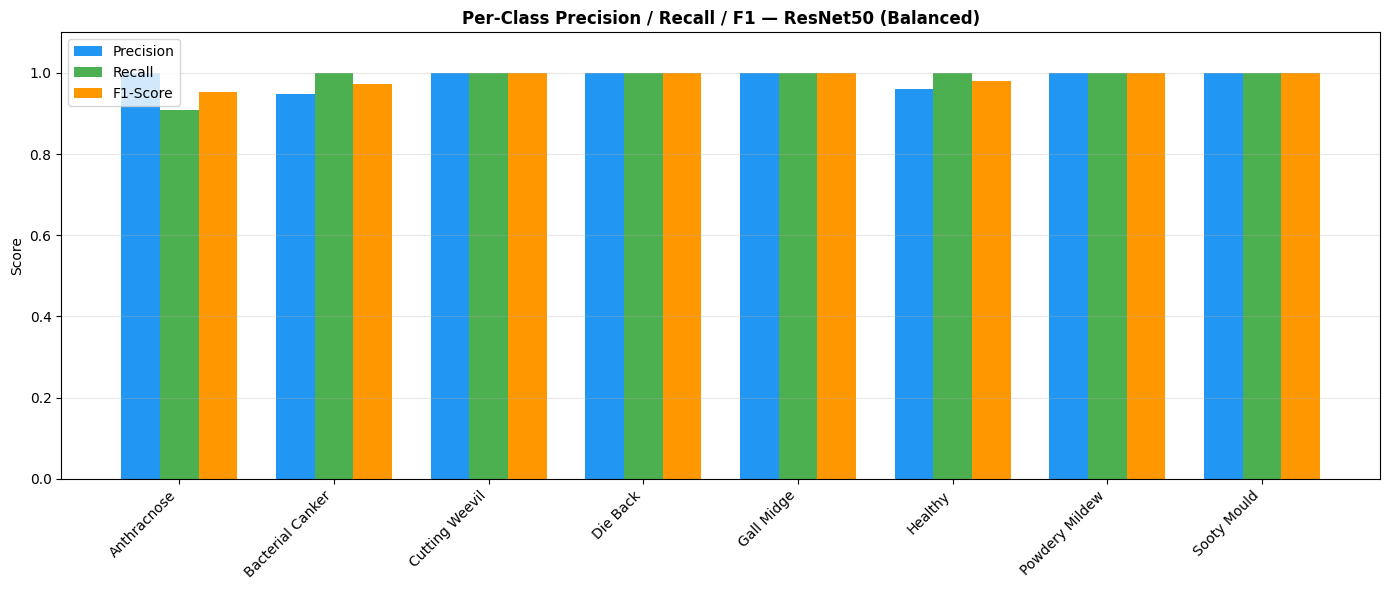

In [24]:
# ── 19. Per-Class Metrics Bar Chart ─────────────────────────────────
report = classification_report(y_true, y_pred,
    target_names=CLASS_NAMES, output_dict=True)
mdf = pd.DataFrame(report).T.iloc[:NUM_CLASSES][['precision', 'recall', 'f1-score']]

x = np.arange(NUM_CLASSES); w = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, mdf['precision'], w, label='Precision', color='#2196F3')
ax.bar(x,     mdf['recall'],    w, label='Recall',    color='#4CAF50')
ax.bar(x + w, mdf['f1-score'],  w, label='F1-Score',  color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1 — ResNet50 (Balanced)',
              fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

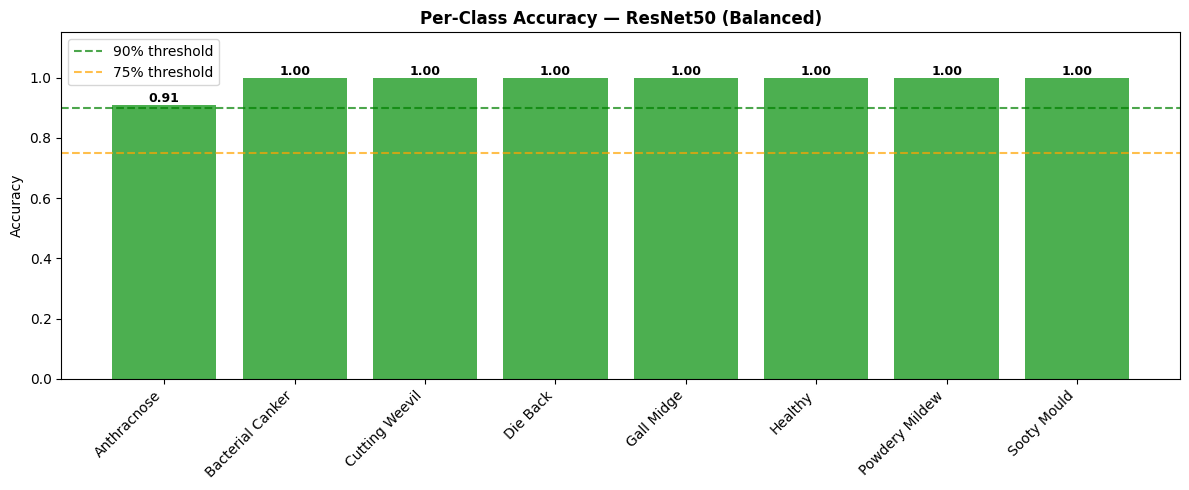

In [25]:
# ── 20. Per-Class Accuracy Bar Chart ────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors_acc = ['#4CAF50' if a >= 0.9 else '#FF9800' if a >= 0.75
              else '#F44336' for a in per_class_acc]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors_acc)
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0.90, color='green',  linestyle='--', alpha=0.7, label='90% threshold')
ax.axhline(0.75, color='orange', linestyle='--', alpha=0.7, label='75% threshold')
ax.set_ylim(0, 1.15); ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy — ResNet50 (Balanced)', fontweight='bold')
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend(); plt.tight_layout(); plt.show()

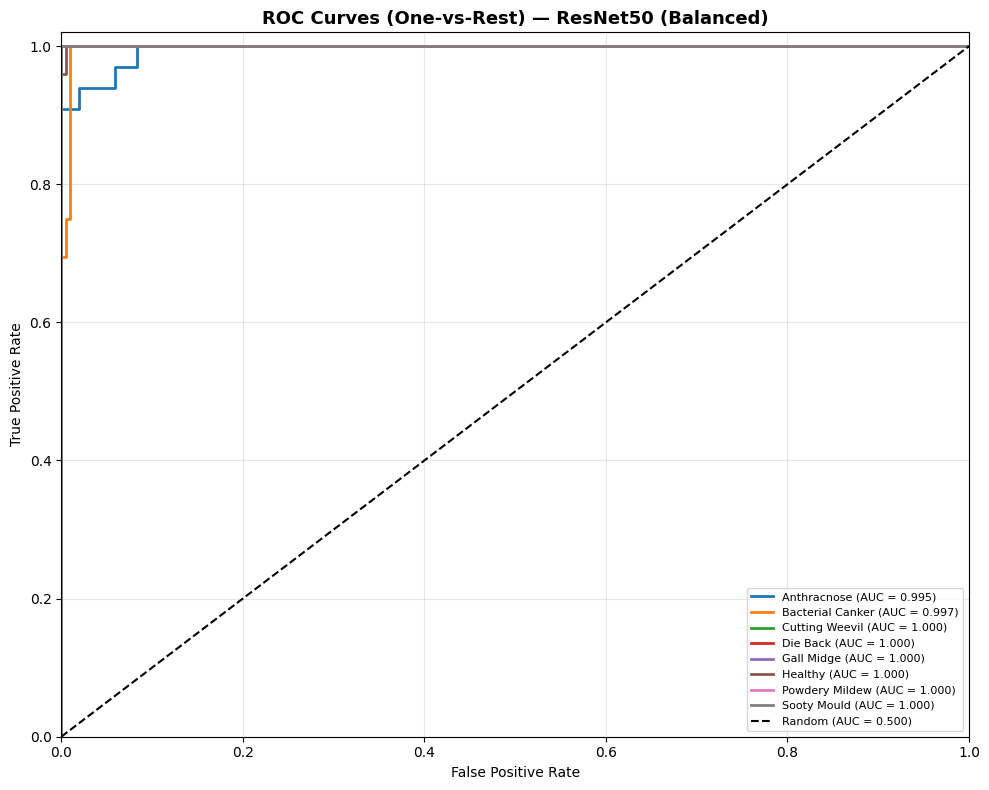

In [26]:
# ── 21. ROC Curves (One-vs-Rest) ────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
roc_palette = sns.color_palette('tab10', NUM_CLASSES)

fig, ax = plt.subplots(figsize=(10, 8))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=roc_palette[i],
            label=f'{cls} (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (One-vs-Rest) — ResNet50 (Balanced)',
              fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

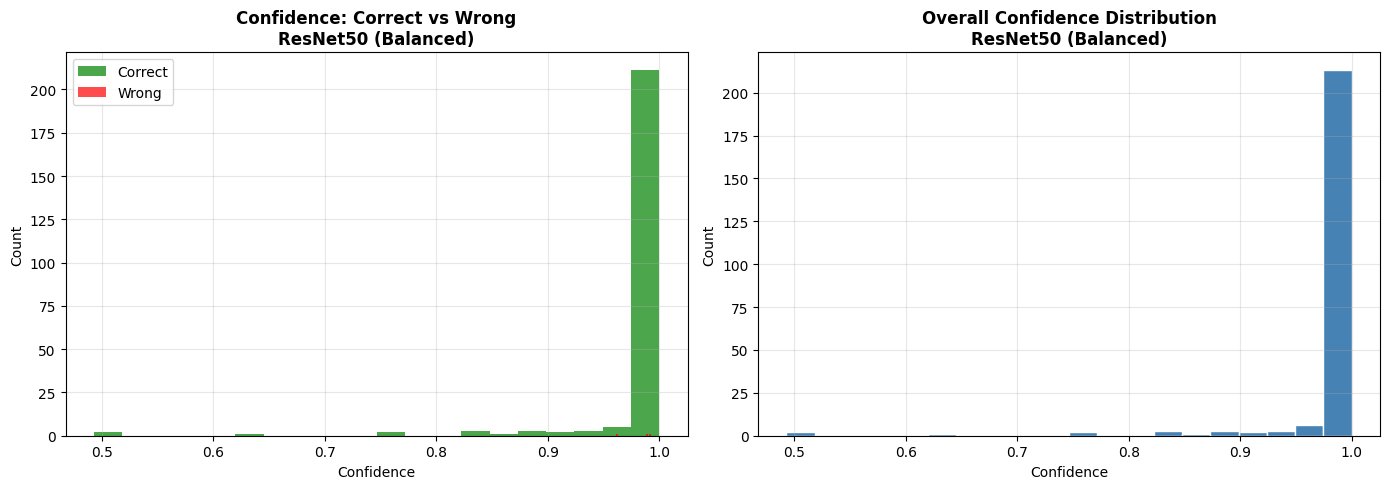

In [27]:
# ── 22. Prediction Confidence Distribution ───────────────────────────
max_conf = np.max(y_proba, axis=1)
correct  = (y_pred == y_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(max_conf[correct],  bins=20, alpha=0.7,
             color='green', label='Correct')
axes[0].hist(max_conf[~correct], bins=20, alpha=0.7,
             color='red',   label='Wrong')
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Count')
axes[0].set_title('Confidence: Correct vs Wrong\nResNet50 (Balanced)',
                   fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(max_conf, bins=20, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Count')
axes[1].set_title('Overall Confidence Distribution\nResNet50 (Balanced)',
                   fontweight='bold')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Found 16 validated image filenames belonging to 7 classes.


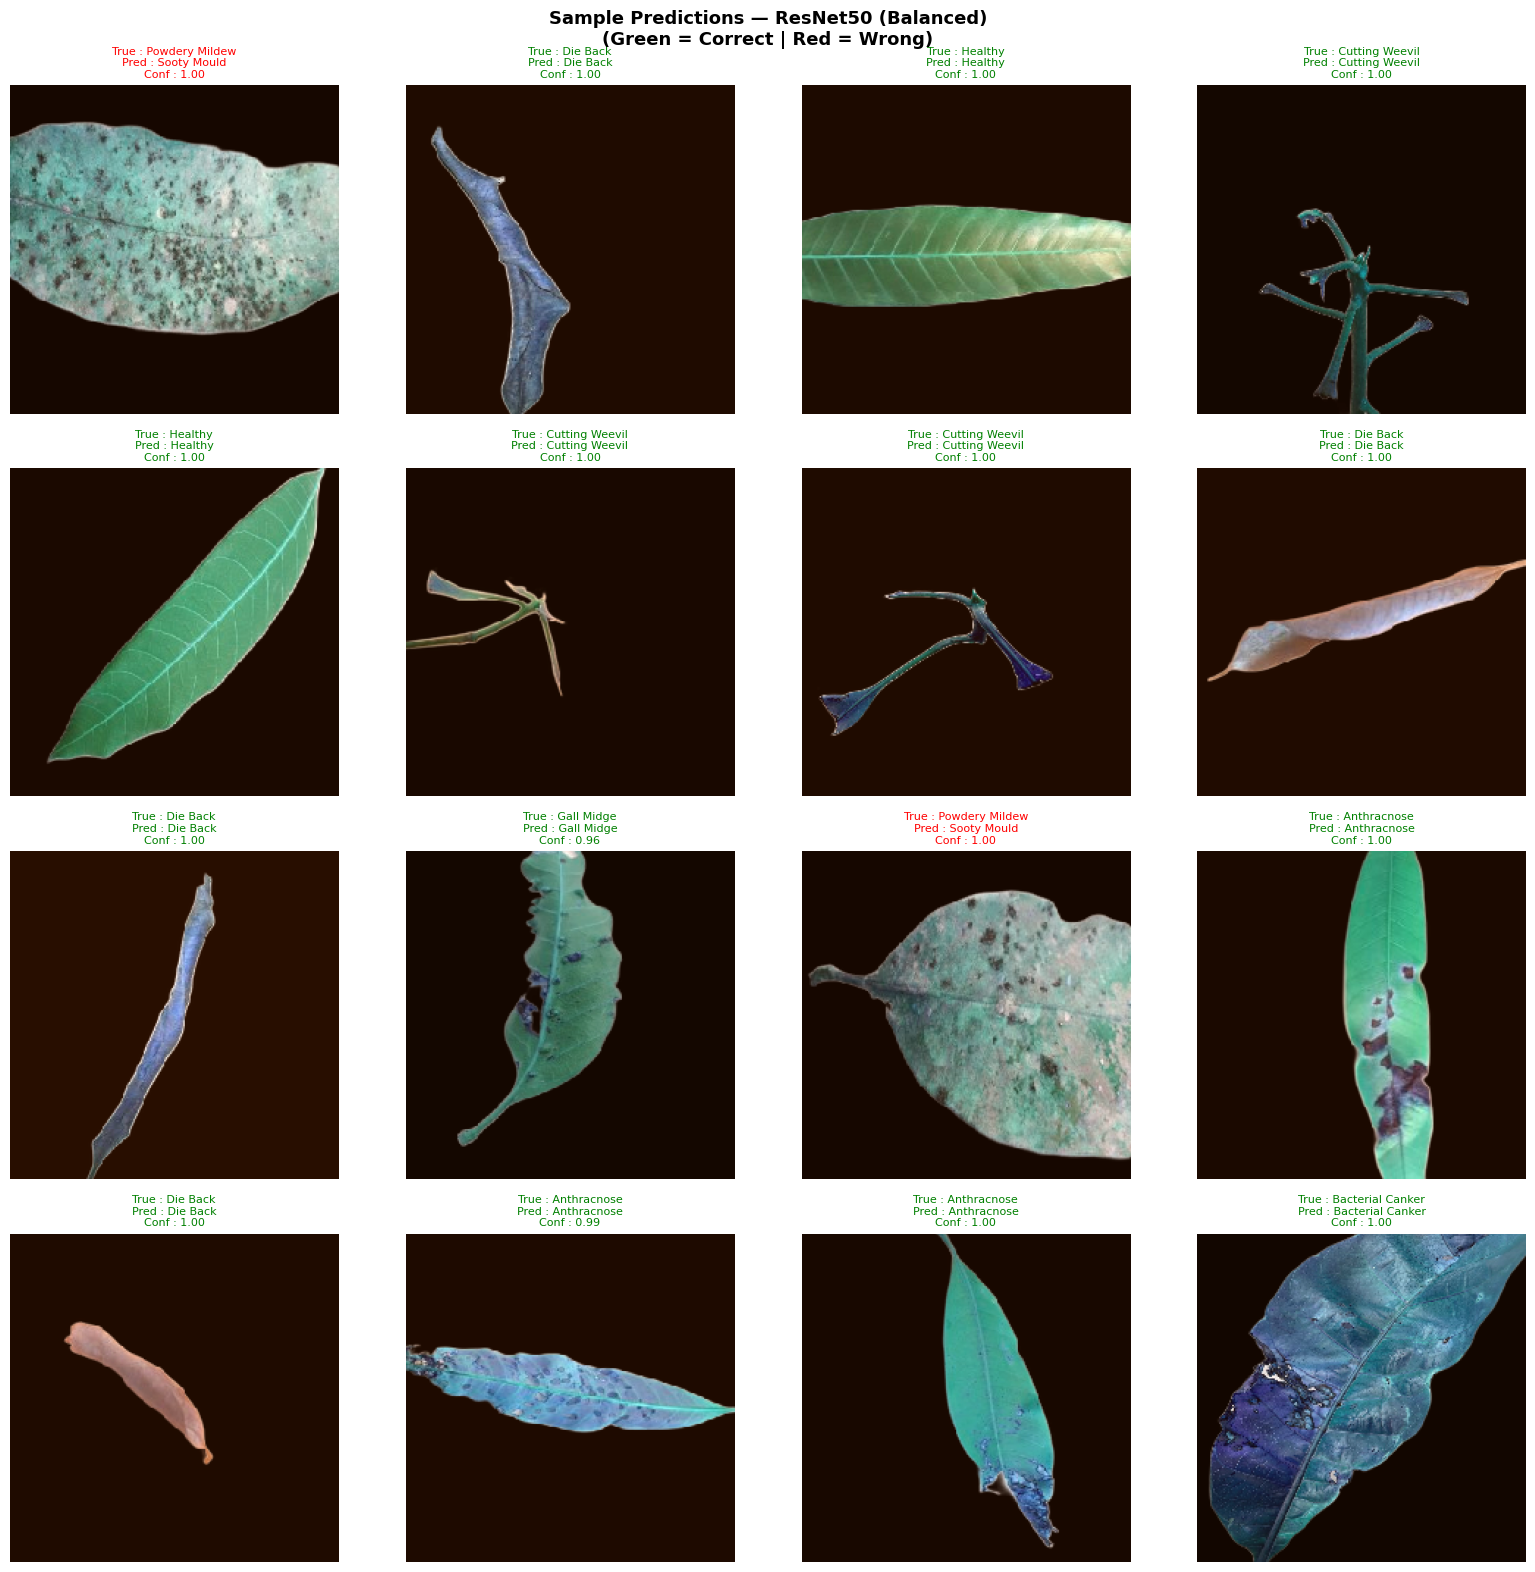

In [28]:
# ── 23. Sample Predictions Grid (4×4) ───────────────────────────────
batch_imgs, batch_lbls = next(
    test_gen.flow_from_dataframe(
        test_df.sample(16, random_state=7),
        x_col='paths', y_col='labels',
        target_size=IMG_SIZE, batch_size=16,
        class_mode='categorical', shuffle=False))

preds_b  = best_model.predict(batch_imgs, verbose=0)
pred_c   = np.argmax(preds_b,  axis=1)
true_c   = np.argmax(batch_lbls, axis=1)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i, ax in enumerate(axes.flatten()):
    img = batch_imgs[i] - batch_imgs[i].min()
    img = (img / img.max() * 255).astype(np.uint8)
    ax.imshow(img); ax.axis('off')
    color = 'green' if pred_c[i] == true_c[i] else 'red'
    ax.set_title(
        f'True : {CLASS_NAMES[true_c[i]]}\n'
        f'Pred : {CLASS_NAMES[pred_c[i]]}\n'
        f'Conf : {preds_b[i, pred_c[i]]:.2f}',
        color=color, fontsize=8)
plt.suptitle('Sample Predictions — ResNet50 (Balanced)\n'
             '(Green = Correct | Red = Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

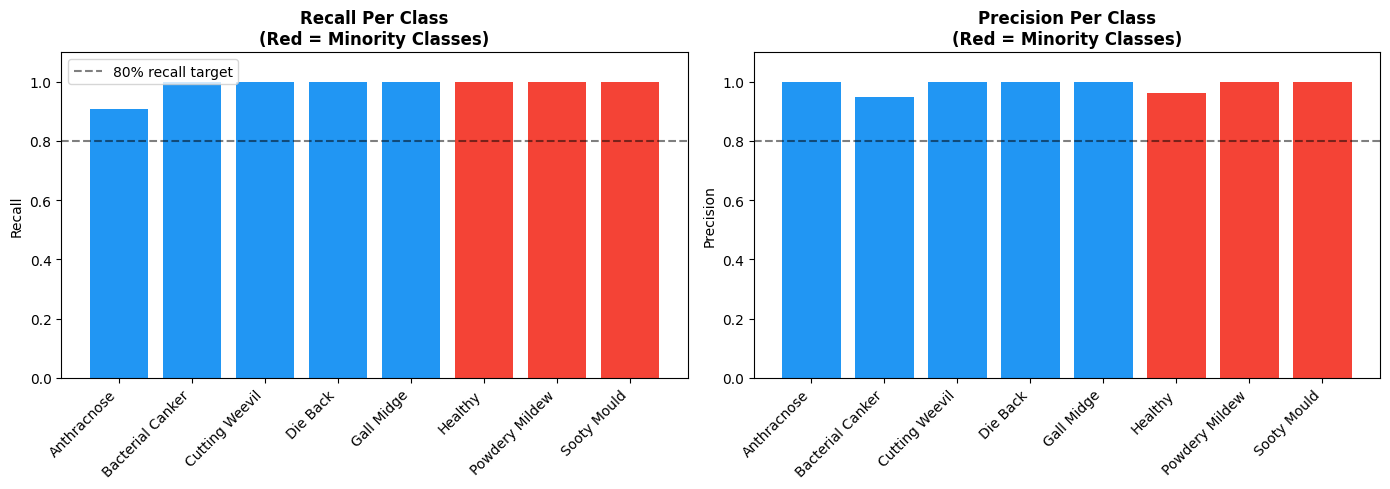

In [29]:
# ── 24. Minority Class Performance Focus ────────────────────────
# Shows improvement on Powdery Mildew and Healthy classes
MINORITY_CLASSES = ['Powdery Mildew', 'Sooty Mould', 'Healthy']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall comparison for minority classes
recall_vals = [report[cls]['recall']
               if cls in report else 0
               for cls in CLASS_NAMES]
prec_vals   = [report[cls]['precision']
               if cls in report else 0
               for cls in CLASS_NAMES]

colors_recall = ['#F44336' if cls in MINORITY_CLASSES
                 else '#2196F3' for cls in CLASS_NAMES]

axes[0].bar(CLASS_NAMES, recall_vals, color=colors_recall)
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel('Recall')
axes[0].set_title('Recall Per Class\n(Red = Minority Classes)',
                   fontweight='bold')
axes[0].axhline(0.8, color='black', linestyle='--', alpha=0.5,
                label='80% recall target')
axes[0].legend()

axes[1].bar(CLASS_NAMES, prec_vals, color=colors_recall)
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision Per Class\n(Red = Minority Classes)',
                   fontweight='bold')
axes[1].axhline(0.8, color='black', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


  ResNet50 (Balanced) — Final Summary
     Split     Loss  Accuracy
     Train 0.143559  0.990885
Validation 0.187375  0.974468
      Test 0.191522  0.987288

Train-Val Accuracy Gap : 0.0164
✓  Model appears well-fitted


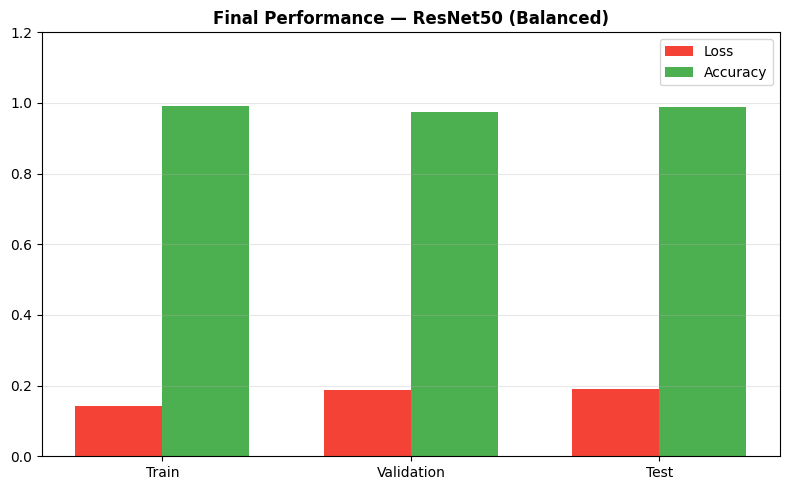

In [30]:
# ── 25. Final Summary ───────────────────────────────────────────────
train_eval = best_model.evaluate(train_flow, verbose=0)
val_eval   = best_model.evaluate(val_flow,   verbose=0)
test_eval  = best_model.evaluate(test_flow,  verbose=0)

summary_df = pd.DataFrame({
    'Split'   : ['Train', 'Validation', 'Test'],
    'Loss'    : [train_eval[0], val_eval[0], test_eval[0]],
    'Accuracy': [train_eval[1], val_eval[1], test_eval[1]]
})

border = '=' * 55
print(f'\n{border}')
print(f'  ResNet50 (Balanced) — Final Summary')
print(f'{border}')
print(summary_df.to_string(index=False))

gap = train_eval[1] - val_eval[1]
print(f'\nTrain-Val Accuracy Gap : {gap:.4f}')
if   gap > 0.10: print('⚠  OVERFITTING  detected (gap > 10%)')
elif train_eval[1] < 0.75: print('⚠  UNDERFITTING detected (train acc < 75%)')
else: print('✓  Model appears well-fitted')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x_s = np.arange(3); w_s = 0.35
ax.bar(x_s - w_s/2,
       [train_eval[0], val_eval[0], test_eval[0]],
       w_s, label='Loss', color='#F44336')
ax.bar(x_s + w_s/2,
       [train_eval[1], val_eval[1], test_eval[1]],
       w_s, label='Accuracy', color='#4CAF50')
ax.set_xticks(x_s)
ax.set_xticklabels(['Train', 'Validation', 'Test'])
ax.set_title('Final Performance — ResNet50 (Balanced)',
              fontweight='bold')
ax.set_ylim(0, 1.2); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()